# Centralidades de cercaníe a intermediación

**Instrucciones de la actividad**

Revisa el siguiente cuaderno de trabajo y realiza las actividades:





Centralidades de cercanía e intermediación.ipynb




Encuentra los vértices de mayor centralidad de la mini red:

Usando la centralidad de cercanía
Usando Intermediación
Elige una base de datos (la misma que usaste en la actividad de centralidad de grado y de eigenvector) y encuentra los vértices de mayor centralidad, usando centralidad de cercanía y de intermediación.



En ambas redes, realiza un análisis: ¿qué se puede decir de los vértices de mayor y menor centralidad? ¿Tiene sentido? Justifica ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado, eigenvector, hubs y authorities, Katz y PageRank? Para los vértices que bajan o suben de centralidad: (a) ¿qué se puede decir de sus vecinos? (b) ¿están en algún conjunto mínimo de nodos de corte?



En ambas redes realizar cuatro visualizaciones personalizando el tamaño y color de cada nodo de acuerdo a su centralidad, respecto a centralidad de cercanía y respecto a la de intermediación.

Cargamos las paqueterías:

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Ejemplo 1

In [2]:
stark_targaryen = ['Rickard','Lyarra','Aerys','Rhaella','Catelyn','Ned','Lyanna','Rhaegar','Elia','Viserys','Daenerys',
                   'Brandon', 'Benjen', 'Robb', 'Sansa', 'Arya', 'Bran', 'Rickon', 'Rhaenys', 'Aegon','Jon']

parents = [('Rickard','Ned'),('Rickard','Lyanna'),('Rickard','Brandon'),('Rickard','Benjen'),
           ('Lyarra','Ned'),('Lyarra','Lyanna'),('Lyarra','Brandon'),('Lyarra','Benjen'),
           ('Aerys','Rhaegar'),('Aerys','Viserys'),('Aerys','Daenerys'),
           ('Rhaella','Rhaegar'),('Rhaella','Viserys'),('Rhaella','Daenerys'),
           ('Catelyn','Robb'),('Catelyn','Sansa'), ('Catelyn','Arya'), ('Catelyn','Bran'), ('Catelyn','Rickon'),
           ('Ned','Robb'),('Ned','Sansa'), ('Ned','Arya'), ('Ned','Bran'), ('Ned','Rickon'),
           ('Rhaegar','Rhaenys'), ('Rhaegar','Aegon'),('Elia','Rhaenys'), ('Elia','Aegon'),
           ('Lyanna','Jon'),('Rhaegar','Jon')]

In [3]:
G=nx.Graph()

In [4]:
G.add_nodes_from(stark_targaryen)
G.add_edges_from(parents)

### Centralidad de cercanía

Usamos la función "closeness_centrality" para calcular la centralidad de grado de los nodos.

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.closeness_centrality.html#networkx.algorithms.centrality.closeness_centrality

Después los ordenamos.

In [5]:
close_centralidades=nx.closeness_centrality(G)
dict(sorted(close_centralidades.items(), key=lambda item:item[1], reverse=True))

{'Lyanna': 0.37037037037037035,
 'Rickard': 0.36363636363636365,
 'Lyarra': 0.36363636363636365,
 'Jon': 0.3508771929824561,
 'Ned': 0.3333333333333333,
 'Rhaegar': 0.3225806451612903,
 'Brandon': 0.2777777777777778,
 'Benjen': 0.2777777777777778,
 'Aerys': 0.2597402597402597,
 'Rhaella': 0.2597402597402597,
 'Robb': 0.2597402597402597,
 'Sansa': 0.2597402597402597,
 'Arya': 0.2597402597402597,
 'Bran': 0.2597402597402597,
 'Rickon': 0.2597402597402597,
 'Rhaenys': 0.25316455696202533,
 'Aegon': 0.25316455696202533,
 'Catelyn': 0.22727272727272727,
 'Viserys': 0.2127659574468085,
 'Daenerys': 0.2127659574468085,
 'Elia': 0.20833333333333334}

Podemos notar que Jon ya no es el más importante, como sucedía en Katz y PageRank, sin emmbargo, sigue siendo de los más importantes.

Podemos visualizar:

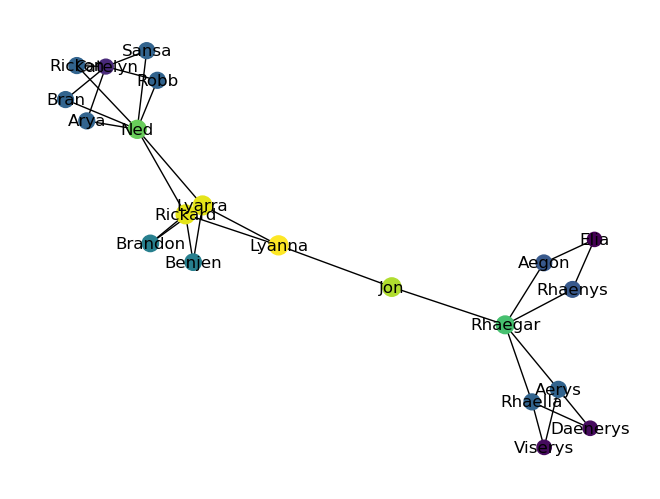

In [6]:
close_lista = [close_centralidades[i] for i in G]
close_sizes = np.array(close_lista)
close_colors = np.array([close_centralidades[i] for i in G])
nx.draw(G,with_labels=True,node_size = 500*close_sizes,node_color = close_colors, cmap = 'viridis')

Viendo la red, notamos que Lyanna está en el "centro" de la red, lo que justifica que sea la de mayor centralidad.

### Centralidad de intermediación

Usamos la función "betweenness_centrality" para calcular la centralidad de grado de los nodos.

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html#networkx.algorithms.centrality.betweenness_centrality

Después los ordenamos:

In [7]:
btw_centralidades=nx.betweenness_centrality(G)
dict(sorted(btw_centralidades.items(), key=lambda item:item[1], reverse=True))

{'Rhaegar': 0.5464912280701754,
 'Lyanna': 0.5223684210526316,
 'Jon': 0.5052631578947369,
 'Ned': 0.4697368421052632,
 'Rickard': 0.2763157894736842,
 'Lyarra': 0.2763157894736842,
 'Aerys': 0.09210526315789473,
 'Rhaella': 0.09210526315789473,
 'Rhaenys': 0.04736842105263158,
 'Aegon': 0.04736842105263158,
 'Catelyn': 0.02631578947368421,
 'Robb': 0.01578947368421053,
 'Sansa': 0.01578947368421053,
 'Arya': 0.01578947368421053,
 'Bran': 0.01578947368421053,
 'Rickon': 0.01578947368421053,
 'Elia': 0.002631578947368421,
 'Viserys': 0.0017543859649122805,
 'Daenerys': 0.0017543859649122805,
 'Brandon': 0.0013157894736842105,
 'Benjen': 0.0013157894736842105}

Podemos notar que Rhaegar ahora es el nodo más central, pasando del lugar 6 (en cercanía) al 1. Jon aumentó un lugar y Lyanna ahora es el número 2. Podemos visualizar:

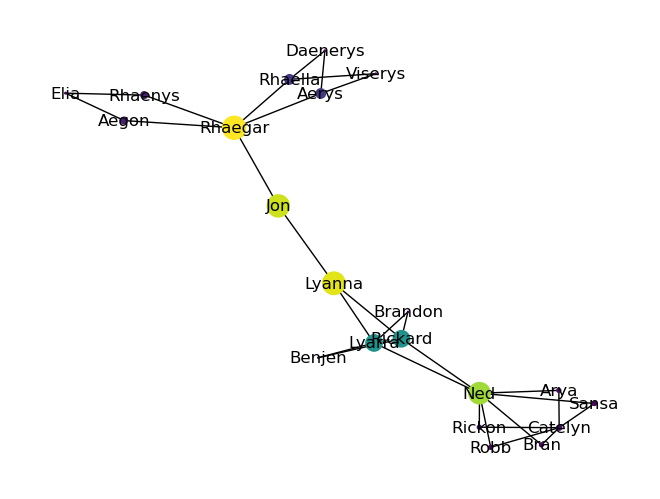

In [8]:
btw_lista = [btw_centralidades[i] for i in G]
btw_sizes = np.array(btw_lista)
btw_colors = np.array([btw_centralidades[i] for i in G])
nx.draw(G,with_labels=True,node_size = 500*btw_sizes,node_color = btw_colors, cmap = 'viridis')

Podemos notar que los cuatro nodos más importantes son puntos de corte de la red, situados en lugares estratégicos (en cuanto a flujo de la red). 

#### Actividad

Considera la red dirigida. ¿Hay algún cambio considerable en las centralidades (de cercanía e intermediación) en comparación con la red no dirigida? ¿A qué crees que se deba?

## Ejemplo 2

Utilicemos la red de colaboración científica.

In [9]:
datos = pd.read_csv('ca-netscience.mtx', skiprows = 2, header = None,sep = ' ')

aristas = datos[[0,1]].values
G1 = nx.Graph()
G1.add_edges_from(aristas)

Obtengamos las centralidades de cercanía:

In [10]:
close_centralidades_CA=nx.closeness_centrality(G1)
dict(sorted(close_centralidades_CA.items(), key=lambda item:item[1], reverse=True))

{26: 0.25661914460285135,
 95: 0.2490118577075099,
 51: 0.24705882352941178,
 231: 0.24308681672025723,
 100: 0.23290203327171904,
 52: 0.23062843197071384,
 5: 0.22964763061968407,
 44: 0.2223529411764706,
 234: 0.2202797202797203,
 297: 0.2198952879581152,
 232: 0.21976744186046512,
 233: 0.21976744186046512,
 308: 0.2181188690132718,
 337: 0.2181188690132718,
 66: 0.2166189111747851,
 8: 0.21637092157985116,
 169: 0.2158766419189035,
 23: 0.2141643059490085,
 4: 0.21331828442437922,
 21: 0.21307779030439683,
 24: 0.21247892074198987,
 1: 0.21176470588235294,
 236: 0.21176470588235294,
 237: 0.21023359288097887,
 238: 0.21023359288097887,
 170: 0.21,
 235: 0.2097669256381798,
 76: 0.2097669256381798,
 106: 0.20883977900552486,
 107: 0.20757825370675453,
 104: 0.20723684210526316,
 105: 0.20689655172413793,
 40: 0.20667031164570804,
 108: 0.20588235294117646,
 125: 0.20532319391634982,
 155: 0.20510037981551818,
 124: 0.2046561992420141,
 25: 0.20454545454545456,
 27: 0.20454545454545

Podemos notar que hay cambios considerables en el ranking con respecto a Katz y PageRank. Podemos visualizar y comparar con la visualización de Katz y/o PageRank:

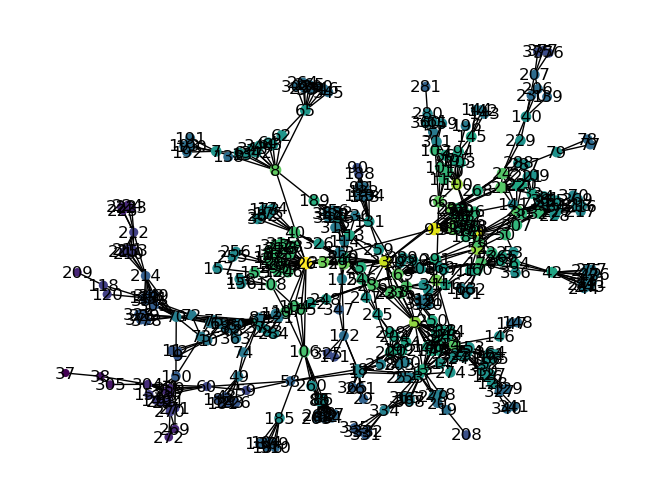

In [11]:
close_lista_CA = [close_centralidades_CA[i] for i in G1]
close_sizes_CA = np.array(close_lista_CA)
close_colors_CA = np.array([close_centralidades_CA[i] for i in G1])
nx.draw(G1,with_labels=True,node_size = 250*close_sizes_CA,node_color = close_colors_CA, cmap = 'viridis')

Podemos notar que los nodos importante aparecen en su mayoría en el "centro de la red". Lo cual va de la mano con la definición de la centralidad.

#### Actividad

Para cada nodo $x_0$ del top 10 y del bottom 10, calcula el promedio de las distancias, $d(x_0,x)$, a cada nodo $x$ de la red. ¿Hay alguna relación con el diámetro de la red? ¿Por qué?

Obtengamos ahora las centralidades de intermediación:

In [12]:
btw_centralidades_CA=nx.betweenness_centrality(G1)
dict(sorted(btw_centralidades_CA.items(), key=lambda item:item[1], reverse=True))

{26: 0.39718418135681216,
 51: 0.34514711880253085,
 169: 0.28602004110719537,
 95: 0.27016272041057465,
 67: 0.2554278416347383,
 5: 0.25062807899754763,
 231: 0.23165391320171955,
 100: 0.22154874297229846,
 44: 0.17487795951990634,
 66: 0.17468615473040033,
 52: 0.1563961713504025,
 4: 0.1520563824733063,
 8: 0.14842752030043013,
 70: 0.12507309633746413,
 1: 0.09146071419938531,
 106: 0.08705598360770775,
 24: 0.07233473046454303,
 201: 0.0700036556166419,
 23: 0.0668686478981772,
 113: 0.06458243852541591,
 15: 0.055437328590038026,
 42: 0.04682609855023648,
 58: 0.046608563849943156,
 214: 0.046608563849943156,
 189: 0.045606586445013614,
 131: 0.045448457607945615,
 17: 0.042828738141152956,
 13: 0.04211420084572179,
 21: 0.04193559271729351,
 65: 0.041747949793926806,
 150: 0.0416286565711853,
 232: 0.04011655485556281,
 233: 0.04011655485556281,
 18: 0.03753773285014777,
 32: 0.0372230275350143,
 140: 0.03660196763645039,
 60: 0.0364475881717261,
 40: 0.0318192116221673,
 170:

#### Actividad

Podemos notar similitudes en el top 10 con respecto a la centralidad de cercanía, ¿tiene sentido? Los nodos 26, 95 y 51 siguen siendo de los más importantes. ¿Qué pasa con los nodos 169 y 67? ¿En qué lugar estaban?

Podemos visualizar:

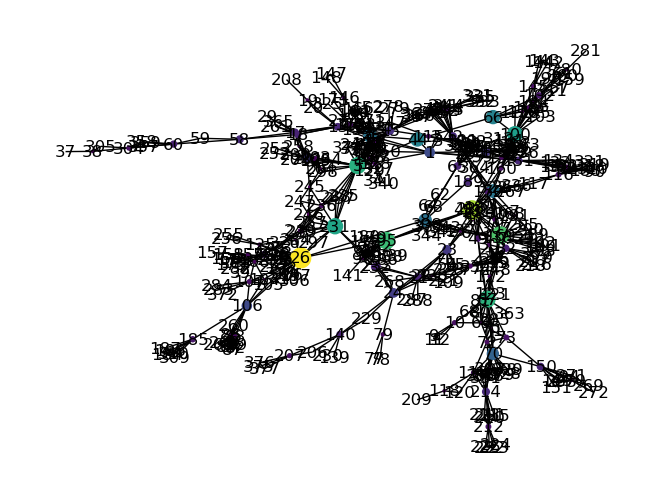

In [13]:
btw_lista_CA = [btw_centralidades_CA[i] for i in G1]
btw_sizes_CA = np.array(btw_lista_CA)
btw_colors_CA = np.array([btw_centralidades_CA[i] for i in G1])
nx.draw(G1,with_labels=True,node_size = 500*btw_sizes_CA,node_color = btw_colors_CA, cmap = 'viridis')

Podemos notar que los nodos más importantes se encuentran en medio de varias trayectorias.

#### Actividad

Para cada nodo del top 10 y del bottom 10, cuenta el número de trayectorias geodésicas que pasan por el nodo. ¿Hay diferencia significativa entre el top 10 y el bottom 10?